In [78]:
import numpy as np
import time
import timeit
import random
import pandas as pd

In [79]:
def mat_prod(A: np.ndarray, B: np.ndarray):
    A_nrow, A_ncol = A.shape
    B_nrow, B_ncol = B.shape
    
    if A_ncol != B_nrow:
        print("Não é possível multiplicar essas matrizes.")
        return
    
    C = np.zeros((A_nrow, B_ncol))
    for i in range(A_nrow):
        for j in range(B_ncol):
            C[i,j] = sum(A[i,k]*B[k,j] for k in range(A_ncol))
    
    return C

In [80]:
def mat_dot_prod(A: np.ndarray, B: np.ndarray):
    A_nrow, A_ncol = A.shape
    B_nrow, B_ncol = B.shape
    
    if A_ncol != B_nrow:
        print("Não é possível multiplicar essas matrizes.")
        return
    
    C = np.zeros((A_nrow, B_ncol))
    for i in range(A_nrow):
        for j in range(B_ncol):
            C[i,j] = np.dot(A[i,:],B[:,j])
    
    return C

In [81]:
def benchmark(func, *args, num_times = 2):
    for i in range(2):
        func(*args)
    
    arr = np.zeros(num_times)
    
    for i in range(num_times):
        initial_time = time.perf_counter()
        func(*args)
        final_time = time.perf_counter()
        
        arr[i] = final_time - initial_time
        
    min = arr.min()
    
    return min

In [82]:
sizes = [(5,5), (10,10), (15,15)]
sizes_long = [(100,400), (50, 500)]
sizes_wide = [(400, 100), (500, 50)]



    

In [83]:
data_mat_prod = []

for size in sizes:
    i, j = size
    tempo_estavel = benchmark(mat_prod, np.random.randint(1, 100, size), np.random.randint(1, 100, size))
    data_mat_prod.append({"size": i, "process_time": tempo_estavel})
    
df_mat_prod = pd.DataFrame(data_mat_prod)
df_mat_prod

,size,process_time
0,5,0.000102
1,10,0.000688
2,15,0.002199


In [84]:
latex_table = df_mat_prod.to_latex(index=False)
print(latex_table)

\begin{tabular}{rr}
\toprule
size & process_time \\
\midrule
5 & 0.000102 \\
10 & 0.000688 \\
15 & 0.002199 \\
\bottomrule
\end{tabular}



In [85]:
data_mat_prod_long = []

for size in sizes_long:
    i, j = size
    tempo_estavel = benchmark(mat_prod, np.random.randint(1, 100, (i,j)), np.random.randint(1, 100, (j,i)))
    data_mat_prod_long.append({"size": i, "process_time": tempo_estavel})
    
df_mat_prod_long = pd.DataFrame(data_mat_prod_long)
df_mat_prod_long

,size,process_time
0,100,1.060265
1,50,0.354850


In [86]:
latex_table_long = df_mat_prod_long.to_latex(index=False)
print(latex_table_long)

\begin{tabular}{rr}
\toprule
size & process_time \\
\midrule
100 & 1.060265 \\
50 & 0.354850 \\
\bottomrule
\end{tabular}



In [87]:
data_mat_prod_wide = []

for size in sizes_wide:
    i, j = size
    tempo_estavel = benchmark(mat_prod, np.random.randint(1, 100, (i,j)), np.random.randint(1, 100, (j,i)))
    data_mat_prod_wide.append({"size": size, "process_time": tempo_estavel})
    
df_mat_prod_wide = pd.DataFrame(data_mat_prod_wide)
df_mat_prod_wide

,size,process_time
0,"(400, 100)",4.517962
1,"(500, 50)",3.407581


In [88]:
latex_table_wide = df_mat_prod_wide.to_latex(index=False)
print(latex_table_wide)

\begin{tabular}{lr}
\toprule
size & process_time \\
\midrule
(400, 100) & 4.517962 \\
(500, 50) & 3.407581 \\
\bottomrule
\end{tabular}



<Axes: title={'center': 'Desempenho'}, xlabel='size'>

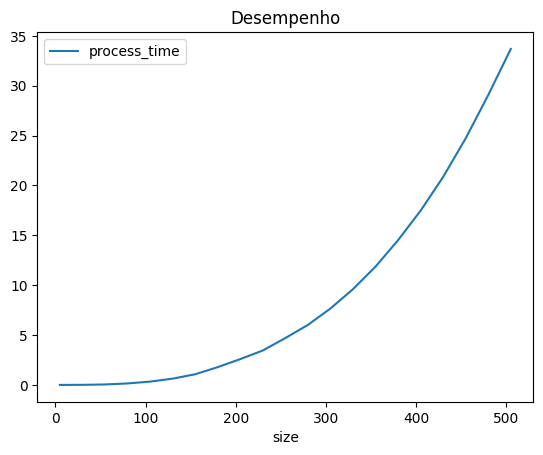

In [90]:
data = []         
tempo_estavel = 0

for n in range(5, 1025, 25):
    if tempo_estavel < 30:
        size = (n,n)
        tempo_estavel = benchmark(mat_prod, np.random.randint(1, 100, size), np.random.randint(1, 100, size))
    
        data.append({"size": n, "process_time": tempo_estavel})


df_data = pd.DataFrame(data)
df_data.plot(x="size", y= "process_time", title="Desempenho")
